# 02 · Data center growth in California (RQ1)

Chapter 2 of *Mapping the Consumption Gap*. Reproduces the national construction-spending chart with rigor, tests for structural breaks, builds the California proxies, assembles every vintage of the CEC energization tiers, and answers RQ1 in a table.

Outputs are produced by `scripts/run_chapter2.py` from `src/ch2_growth.py`; this notebook displays them. Bootstrap p-values use 199 moving-block replications; rerunning the pipeline reproduces them exactly (fixed seeds).

| Step | Sources (manifest ids) |
|---|---|
| 1-2. Census chart, breaks, forecasts | `census_c30_privsatime`, `census_c30_privtime` |
| 3. California proxies | `qcew_518210_*`, `cbre_*_infogram_*` (via `cbre_california_market_series.csv`), `epoch_data_center_timelines`, `epoch_data_centers` |
| 4. Tier vintages | `cec_dc_forecast_2024iepr`, `cec_prelim_dc_forecast_2025`, `cec_dc_methodology_memo_2026`, `cec_assembly_hearing_2026_01_28`, `cec_tn266008`, `cec_tn268459`, `cec_tn272026` |
| 5. RQ1 denominators | `caiso_key_statistics_2026_08`, chapter 1 tables, `cec_tn268124`, `cec_tn268727`, `cec_tn268824` |


In [1]:
import sys, json, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))
import pandas as pd, numpy as np
from IPython.display import Image, display
from src.paths import PROCESSED, FIGURES
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 80)
def show(name): display(Image(filename=str(FIGURES / f"{name}.png")))
def table(name, **kw): return pd.read_csv(PROCESSED / f"{name}.csv", **kw)

## 1. The Census chart, reproduced from the raw C30 workbook

US private construction spending in the Census Bureau's "Data center" category (a line item under nonresidential/office since January 2014), seasonally adjusted annual rate, millions of dollars. The second panel is month-over-month growth.

In [2]:
c = table("ch2_census_c30_data_center", index_col=0, parse_dates=True)
c[["data_center_saar","data_center_nsa","nonresidential_saar","dc_share_of_nonres_pct","mom_growth_pct","yoy_growth_pct","flag_saar"]].iloc[[0, 60, 106, 107, -3, -2, -1]].round(2)

,data_center_saar,data_center_nsa,nonresidential_saar,dc_share_of_nonres_pct,mom_growth_pct,yoy_growth_pct,flag_saar
date,,,,,,,
2014-01-31,1637.0,124.0,353903,0.46,NaN,NaN,NaN
2019-01-31,8116.0,631.0,458298,1.77,0.84,33.53,NaN
2022-11-30,13855.0,1120.0,649673,2.13,8.11,30.98,NaN
2022-12-31,14244.0,1153.0,663906,2.15,2.81,25.79,NaN
2026-05-31,65688.0,5627.0,749441,8.76,6.19,36.25,r
2026-06-30,70755.0,6122.0,752375,9.40,7.71,51.02,r
2026-07-31,75166.0,6551.0,755169,9.95,6.23,57.22,p


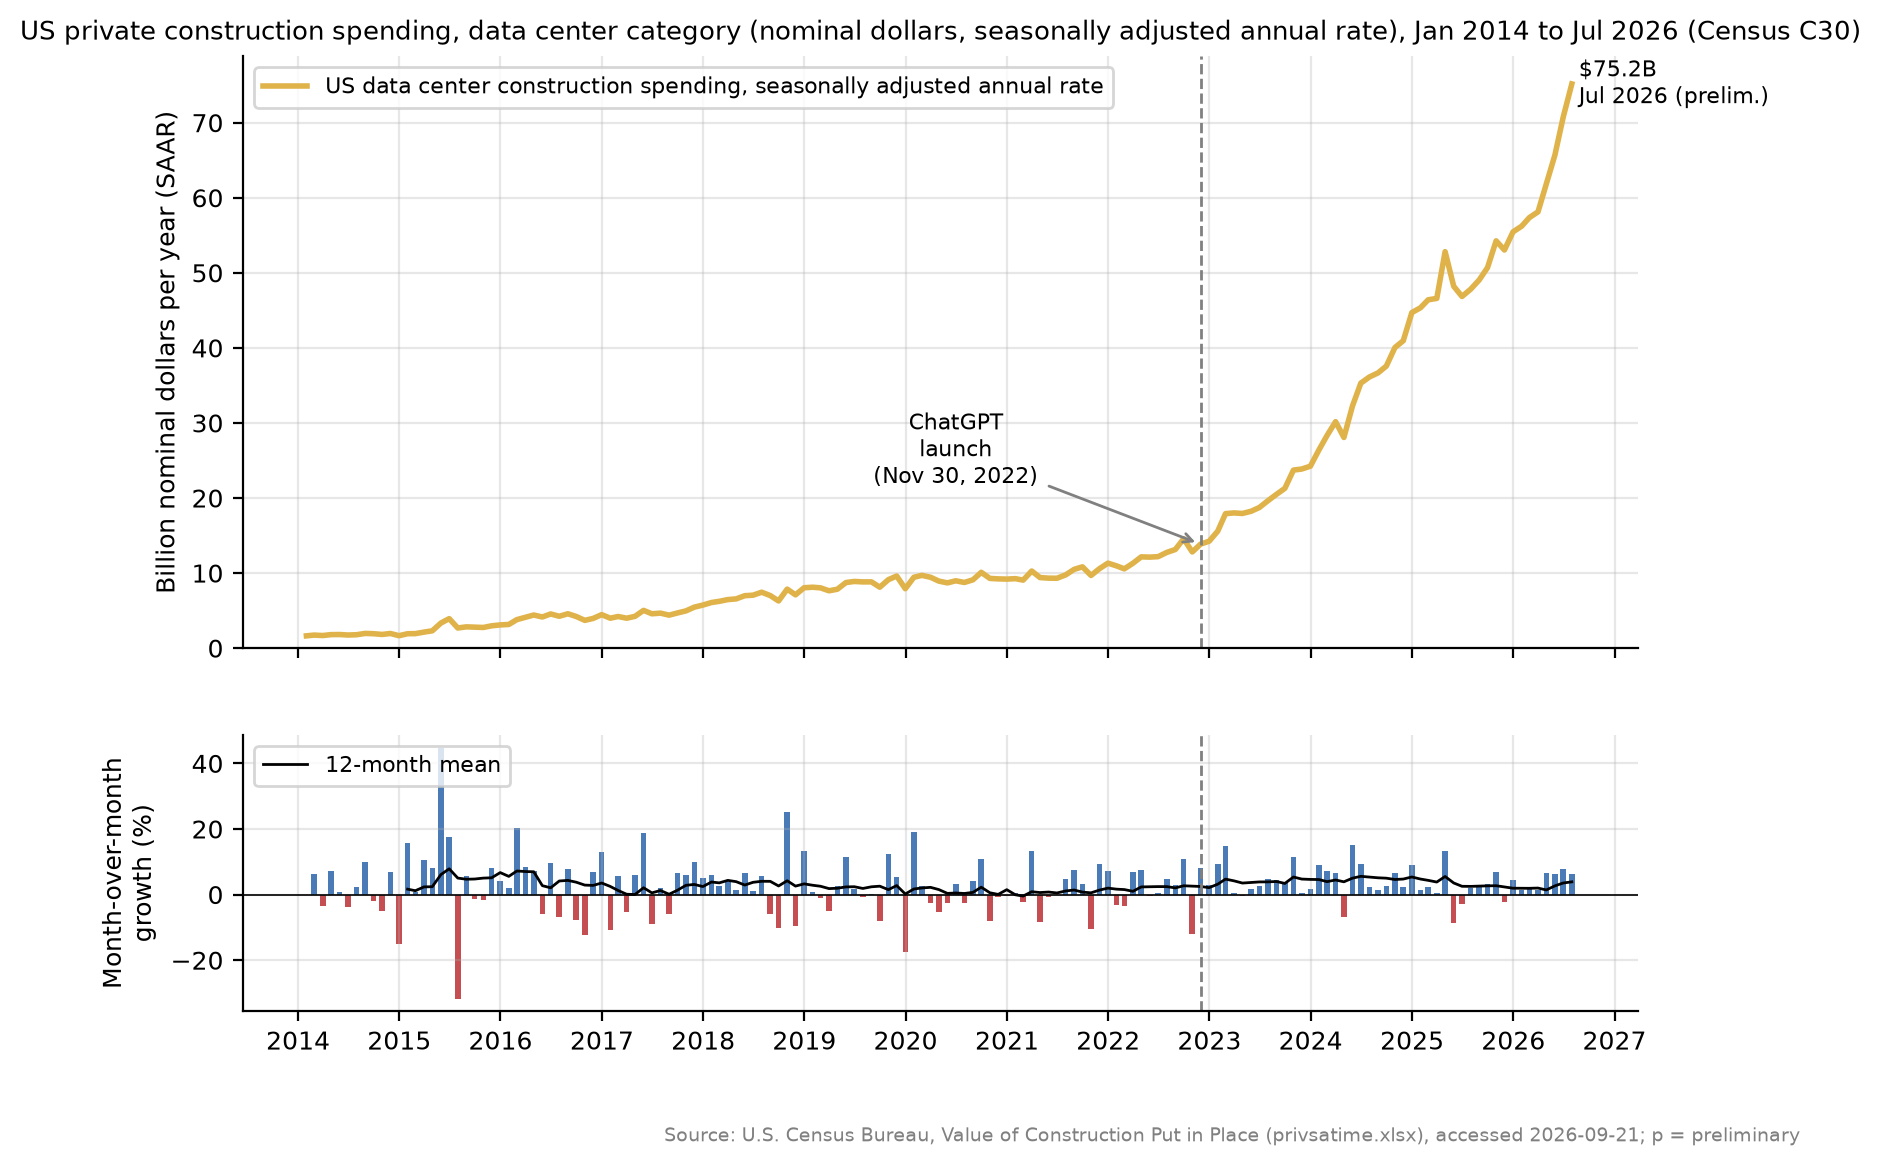

In [3]:
show("fig2_01_census_data_center_construction")

**Reading.** Spending rose from $1.6 billion a year in January 2014 to $13.9 billion in November 2022 and $75.2 billion in July 2026 (preliminary), and data centers went from 0.5 percent to 10 percent of all private nonresidential construction. Month-over-month growth averaged 4.1 percent in 2023-2026 against 1.2 percent in 2019-2021.

## 2. Structural breaks and forecasts on the log series

- **Chow test** at December 2022, the first full month after the November 30, 2022 launch (the November observation stays in the pre-launch segment): break in intercept and slope of the log-linear trend, classical F plus a HAC-robust Wald test.
- **Bai-Perron**: global least-squares search over all partitions with 15 percent trimming (minimum segment 23 months) and up to five breaks (the most the trimming allows, so the choice is uncensored); number of breaks chosen by BIC, by LWZ and by the sequential supF(l+1|l) procedure with moving-block residual bootstrap p-values; supF(0|1) with the same bootstrap; the single-break date with a residual-bootstrap 90 percent interval; `ruptures` dynamic programming as a cross-check.
- **Forecasts**: ARIMA(p,1,q) with drift chosen by AIC, and ETS with damped additive trend, both on log levels, 24 months ahead; point forecasts are back-transformed log medians. A rolling-origin backtest over the last 24 months compares both with naive and drift benchmarks.

In [4]:
summ = json.loads((PROCESSED / "ch2_census_break_summary.json").read_text())
{k: summ[k] for k in ["chow_F","chow_p","wald_hac_p","cagr_pre","cagr_pre_lo","cagr_pre_hi","cagr_post","cagr_post_lo","cagr_post_hi","bp_break1","bp_break1_ci90","bp_supF_1","bp_supF_1_boot_p","bp_breaks_bic","bp_m_bic","bp_m_lwz","bp_m_seq","bp_seq_p","ruptures_dynp","arima","ets"]}

{'chow_F': 62.96421533268214,
 'chow_p': 0.0,
 'wald_hac_p': 3.4823734076782446e-09,
 'cagr_pre': 0.2620363062482236,
 'cagr_pre_lo': 0.21618085742186177,
 'cagr_pre_hi': 0.30962071024949633,
 'cagr_post': 0.5322387091617669,
 'cagr_post_lo': 0.46269313031056103,
 'cagr_post_hi': 0.6050909197578844,
 'bp_break1': '2020-11',
 'bp_break1_ci90': '2020-11 to 2020-11',
 'bp_supF_1': 125.44288008939989,
 'bp_supF_1_boot_p': 0.01,
 'bp_breaks_bic': '2016-10, 2018-12, 2022-03, 2024-06',
 'bp_m_bic': 4,
 'bp_m_lwz': 4,
 'bp_m_seq': 1,
 'bp_seq_p': '1|0: F=125.4 p=0.020; 2|1: F=36.7 p=0.085; 3|2: F=40.6 p=0.020; 4|3: F=40.6 p=0.005',
 'ruptures_dynp': {'1': ['2020-10'],
  '2': ['2018-11', '2022-02'],
  '3': ['2016-09', '2018-11', '2022-02'],
  '4': ['2016-09', '2018-11', '2022-02', '2024-05'],
  '5': ['2016-01', '2017-12', '2020-03', '2022-04', '2024-05']},
 'arima': {'order': [1, 1, 1],
  'aic': -326.35099173744527,
  'drift_per_month': 0.025272101168361087,
  'params': {'x1': 0.025272101168361

In [5]:
pd.DataFrame(summ["sequential"]["levels"]).T.rename_axis("breaks tested (l+1 | l)").round(3)

,supF_seq,boot_p
breaks tested (l+1 | l),,
1,125.443,0.020
2,36.708,0.085
3,40.639,0.020
4,40.639,0.005


In [6]:
table("ch2_census_bai_perron").round(3)

,m,breaks,ssr,bic,lwz,supF_0_m,supF_seq,supF_seq_boot_p
0,0,NaN,5.967,-3.165,-3.101,NaN,NaN,NaN
1,1,2020-11,2.205,-4.061,-3.900,125.443,125.443,0.020
2,2,"2018-12, 2022-03",1.375,-4.433,-4.176,121.090,36.708,0.085
3,3,"2016-10, 2018-12, 2022-03",1.091,-4.565,-4.210,106.544,40.639,0.020
4,4,"2016-10, 2018-12, 2022-03, 2024-06",0.880,-4.680,-4.228,101.896,40.639,0.005
5,5,"2016-02, 2018-01, 2020-04, 2022-05, 2024-06",0.832,-4.636,-4.086,85.744,NaN,NaN


In [7]:
table("ch2_census_segment_growth").round(3)

,segment_start,segment_end,months,cagr,cagr_lo95,cagr_hi95
0,2014-01,2016-09,33,0.527,0.447,0.611
1,2016-10,2018-11,26,0.418,0.365,0.473
2,2018-12,2022-02,39,0.088,0.072,0.105
3,2022-03,2024-05,27,0.611,0.558,0.667
4,2024-06,2026-07,26,0.359,0.311,0.409


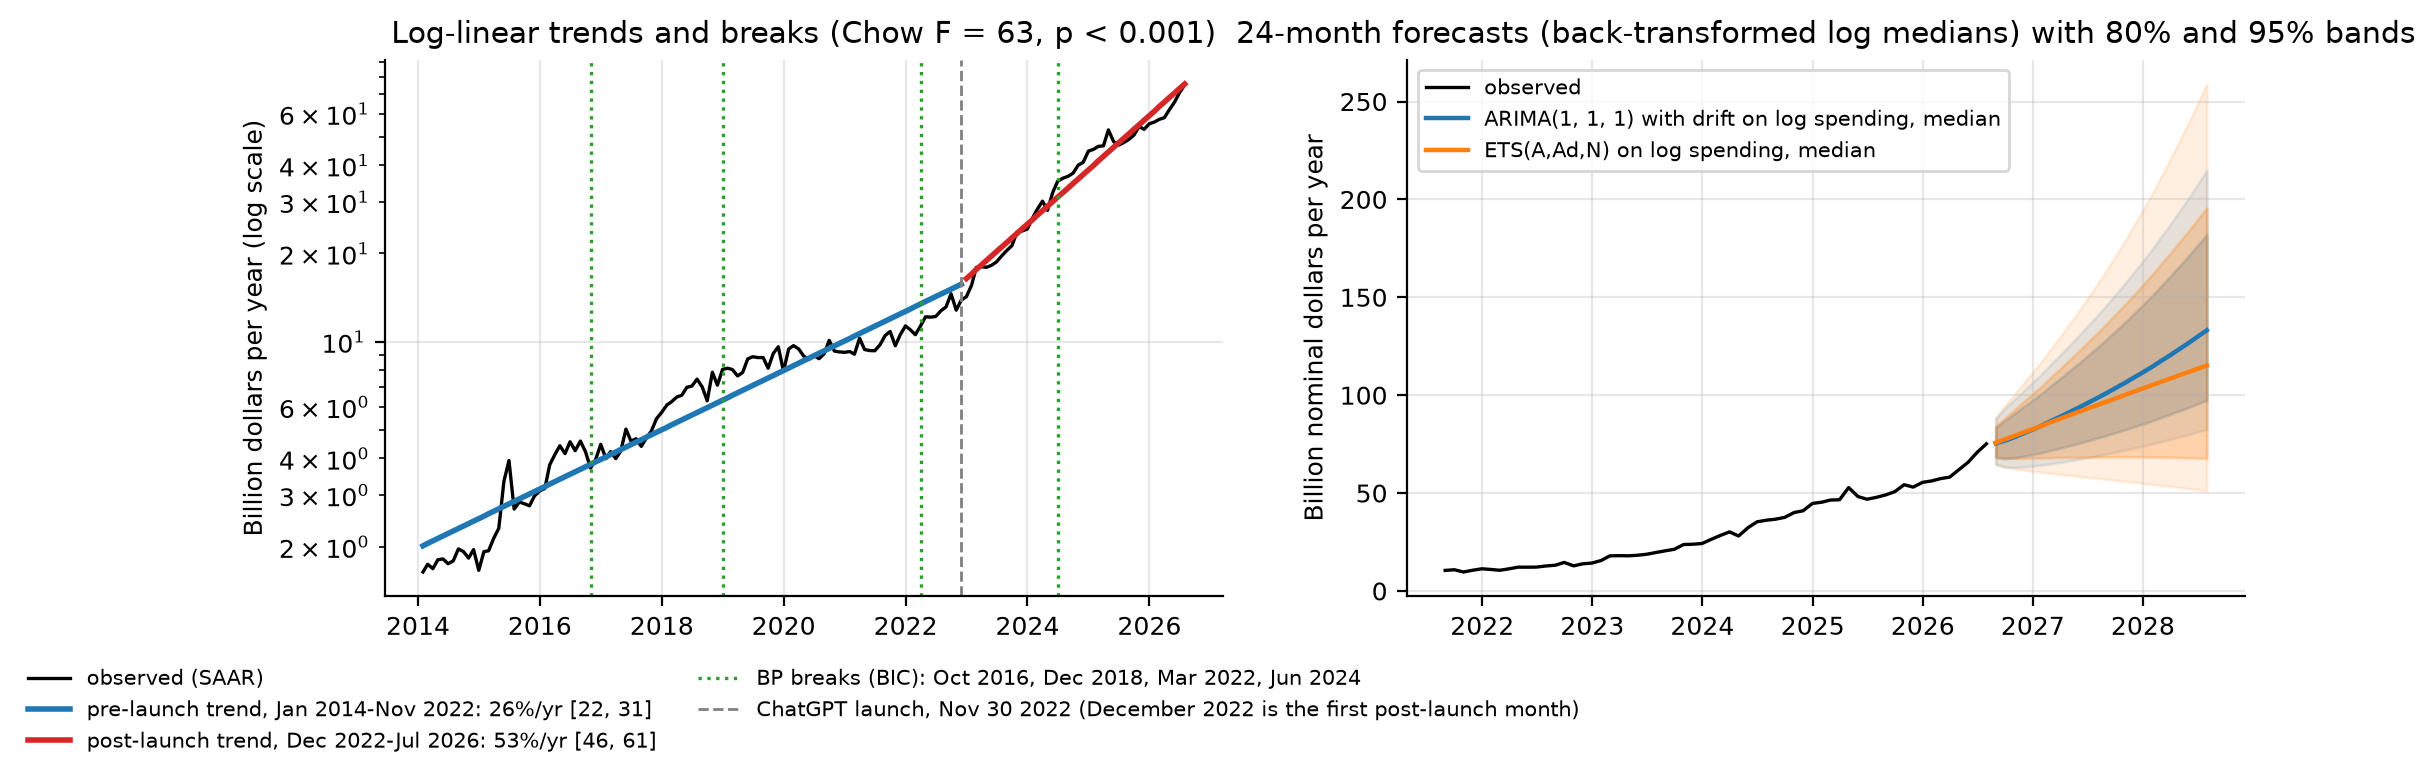

In [8]:
show("fig2_02_census_breaks_and_forecast")

In [9]:
fa = table("ch2_census_forecast_arima", index_col=0, parse_dates=True); fe = table("ch2_census_forecast_ets", index_col=0, parse_dates=True)
pd.concat({"ARIMA": (fa/1000).round(1), "ETS": (fe/1000).round(1)}, axis=1).iloc[[0, 5, 11, 17, 23]]

ARIMA                              ETS                          
             mean  lo80   hi80  lo95   hi95   mean  lo80   hi80  lo95   hi95
2026-08-31   75.4  68.1   83.5  64.6   88.1   75.7  68.2   84.0  64.6   88.8
2027-01-31   84.5  70.7  101.0  64.3  111.0   84.4  68.0  104.7  60.6  117.4
2027-07-31   98.3  78.0  124.0  68.9  140.2   94.8  68.4  131.3  57.6  156.0
2028-01-31  114.4  86.9  150.7  75.1  174.4  105.1  68.4  161.4  54.5  202.6
2028-07-31  133.2  97.4  182.1  82.5  214.9  115.1  67.8  195.6  51.2  258.9

In [10]:
table("ch2_census_forecast_backtest").round(2)

,model,horizon,n,mape_pct,rmse_log,bias_log,coverage80_pct,coverage95_pct
0,"ARIMA (log, drift)",1,24,4.63,0.06,-0.02,95.83,100.00
1,"ARIMA (log, drift)",3,24,8.02,0.09,-0.05,91.67,100.00
2,"ARIMA (log, drift)",6,24,11.64,0.14,-0.08,75.00,100.00
3,"ARIMA (log, drift)",12,24,13.95,0.20,-0.11,66.67,91.67
4,"ETS(A,Ad,N) (log)",1,24,4.86,0.06,-0.03,95.83,100.00
5,"ETS(A,Ad,N) (log)",3,24,8.75,0.11,-0.06,87.50,100.00
6,"ETS(A,Ad,N) (log)",6,24,13.95,0.18,-0.11,75.00,91.67
7,"ETS(A,Ad,N) (log)",12,24,18.85,0.30,-0.20,66.67,79.17
8,drift benchmark (log random walk),1,24,4.04,0.06,-0.01,NaN,NaN
9,drift benchmark (log random walk),3,24,6.62,0.08,-0.03,NaN,NaN


**Reading.** The known-date test is unambiguous (Chow F = 63, p < 0.001; HAC Wald p < 0.001): compound growth was 26 percent a year [22, 31] through November 2022 and 53 percent a year [46, 61] from December 2022, the first full post-launch month (assigning November to the post period, as the first pass did, gave 54). The test dates the trend change; it does not establish that the launch caused it. Letting the data locate breaks changes the story in two respects. BIC and LWZ both choose four breaks (October 2016, December 2018, March 2022, June 2024), so the acceleration began eight months before ChatGPT, in the hyperscaler capital-spending ramp of early 2022, and it has already slowed once: 61 percent a year [56, 67] from March 2022 to May 2024, then 36 percent a year [31, 41] from June 2024 to July 2026, still four times the 9 percent of 2019 to early 2022. The sequential supF(l+1|l) procedure is more conservative: supF(1|0) = 125 rejects no break (p = 0.02) but supF(2|1) = 37 has p = 0.085, so at 5 percent it stops at one break (November 2020), although the third and fourth breaks are each significant once the earlier ones are in place (p = 0.02, 0.005). `ruptures` reproduces all four BIC dates within one month. Both forecasts continue the recent trend with wide bands: roughly $95-100 billion by July 2027 and $115-135 billion by July 2028 (medians), with 95 percent bands spanning $50-260 billion by then. The backtest is the caveat: at a 12-month horizon the MAPE is 14 percent (ARIMA) and 19 percent (ETS) against 13 percent for a log random walk with drift, all forecasts ran low on average, and the 95 percent bands covered 92 and 79 percent of outcomes. National nominal dollars, not California megawatts.

## 3. California proxies: QCEW, CBRE, Epoch

No state-level construction-spending series exists. Three proxies are tested with the same battery (Chow at the first period after November 2022, Bai-Perron):
- BLS QCEW, NAICS 518210, private, California: establishments, employment, wages by quarter (2014 Q1 to 2026 Q1; the BLS open-data API serves no 518210 slice before 2014).
- CBRE Silicon Valley colocation market: MW under construction each half-year since H1 2016 (chapter history table) and inventory (overview tables). Cushman & Wakefield's tables are gated; JLL gives single-period inventory only.
- Epoch AI frontier facilities: cumulative facility power from per-site timelines. The snapshot contains no California observation, which is a limit of the hub's coverage rather than evidence of zero California activity, so only the national series can be tested.

In [11]:
comp = table("ch2_break_test_comparison")
comp[["series","n","start","end","known_break_period","chow_F","chow_p","wald_hac_p","cagr_pre","cagr_post","bp_break1","bp_break1_ci90","bp_m_bic","bp_m_lwz","bp_m_seq","bp_breaks_bic","bp_supF_1_boot_p","note"]].round(3)

,series,n,start,end,known_break_period,chow_F,chow_p,wald_hac_p,cagr_pre,cagr_post,bp_break1,bp_break1_ci90,bp_m_bic,bp_m_lwz,bp_m_seq,bp_breaks_bic,bp_supF_1_boot_p,note
0,"Census data center construction (monthly, SAAR)",151,2014-01,2026-07,2022-12,62.964,0.000,0.0,0.262,0.532,2020-11,2020-11 to 2020-11,4.0,4.0,1.0,"2016-10, 2018-12, 2022-03, 2024-06",0.010,NaN
1,QCEW 518210 California employment (quarterly),49,2014-03,2026-03,2023-03,14.961,0.000,0.0,0.115,-0.003,2016-03,2016-03 to 2021-12,4.0,3.0,0.0,"2016-03, 2018-09, 2021-03, 2023-09",0.035,NaN
2,QCEW 518210 California establishments (quarterly),49,2014-03,2026-03,2023-03,10.956,0.000,0.0,0.114,0.005,2019-03,2016-12 to 2022-09,4.0,4.0,0.0,"2016-03, 2018-03, 2020-12, 2023-06",0.285,NaN
3,QCEW 518210 California wages (quarterly),49,2014-03,2026-03,2023-03,5.530,0.007,0.0,0.217,0.112,2019-03,2016-12 to 2019-06,2.0,1.0,1.0,"2019-03, 2021-12",0.005,NaN
4,CBRE Silicon Valley MW under construction (semiannual),21,2016-06,2026-06,2023-06,0.501,0.614,0.0,0.349,0.040,2020-12,2020-12 to 2020-12,1.0,0.0,0.0,2020-12,0.140,NaN
5,"Epoch frontier sites, United States cumulative MW (monthly)",69,2021-01,2026-09,2022-11,176.134,0.000,0.0,0.000,2.883,2023-01,2023-01 to 2023-01,2.0,2.0,1.0,"2023-01, 2024-04",0.005,NaN
6,"Epoch frontier sites, California cumulative MW",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no California observation in the Epoch snapshot (0 of 87 sites): a coverage ...


In [12]:
comp[["series","bp_seq_p"]].dropna()

,series,bp_seq_p
0,"Census data center construction (monthly, SAAR)",1|0: F=125.4 p=0.020; 2|1: F=36.7 p=0.085; 3|2: F=40.6 p=0.020; 4|3: F=40.6 ...
1,QCEW 518210 California employment (quarterly),1|0: F=24.6 p=0.065; 2|1: F=37.5 p=0.010; 3|2: F=7.4 p=0.215; 4|3: F=11.7 p=...
2,QCEW 518210 California establishments (quarterly),1|0: F=13.8 p=0.290; 2|1: F=36.0 p=0.025; 3|2: F=20.6 p=0.030
3,QCEW 518210 California wages (quarterly),1|0: F=30.7 p=0.005; 2|1: F=6.6 p=0.060; 3|2: F=0.8 p=0.815; 4|3: F=0.8 p=0.450
4,CBRE Silicon Valley MW under construction (semiannual),1|0: F=6.7 p=0.180; 2|1: F=11.5 p=0.030; 3|2: F=11.5 p=0.030; 4|3: F=3.0 p=0...
5,"Epoch frontier sites, United States cumulative MW (monthly)",1|0: F=543.0 p=0.005; 2|1: F=22.0 p=0.115; 3|2: F=2.1 p=0.755; 4|3: F=0.0 p=...


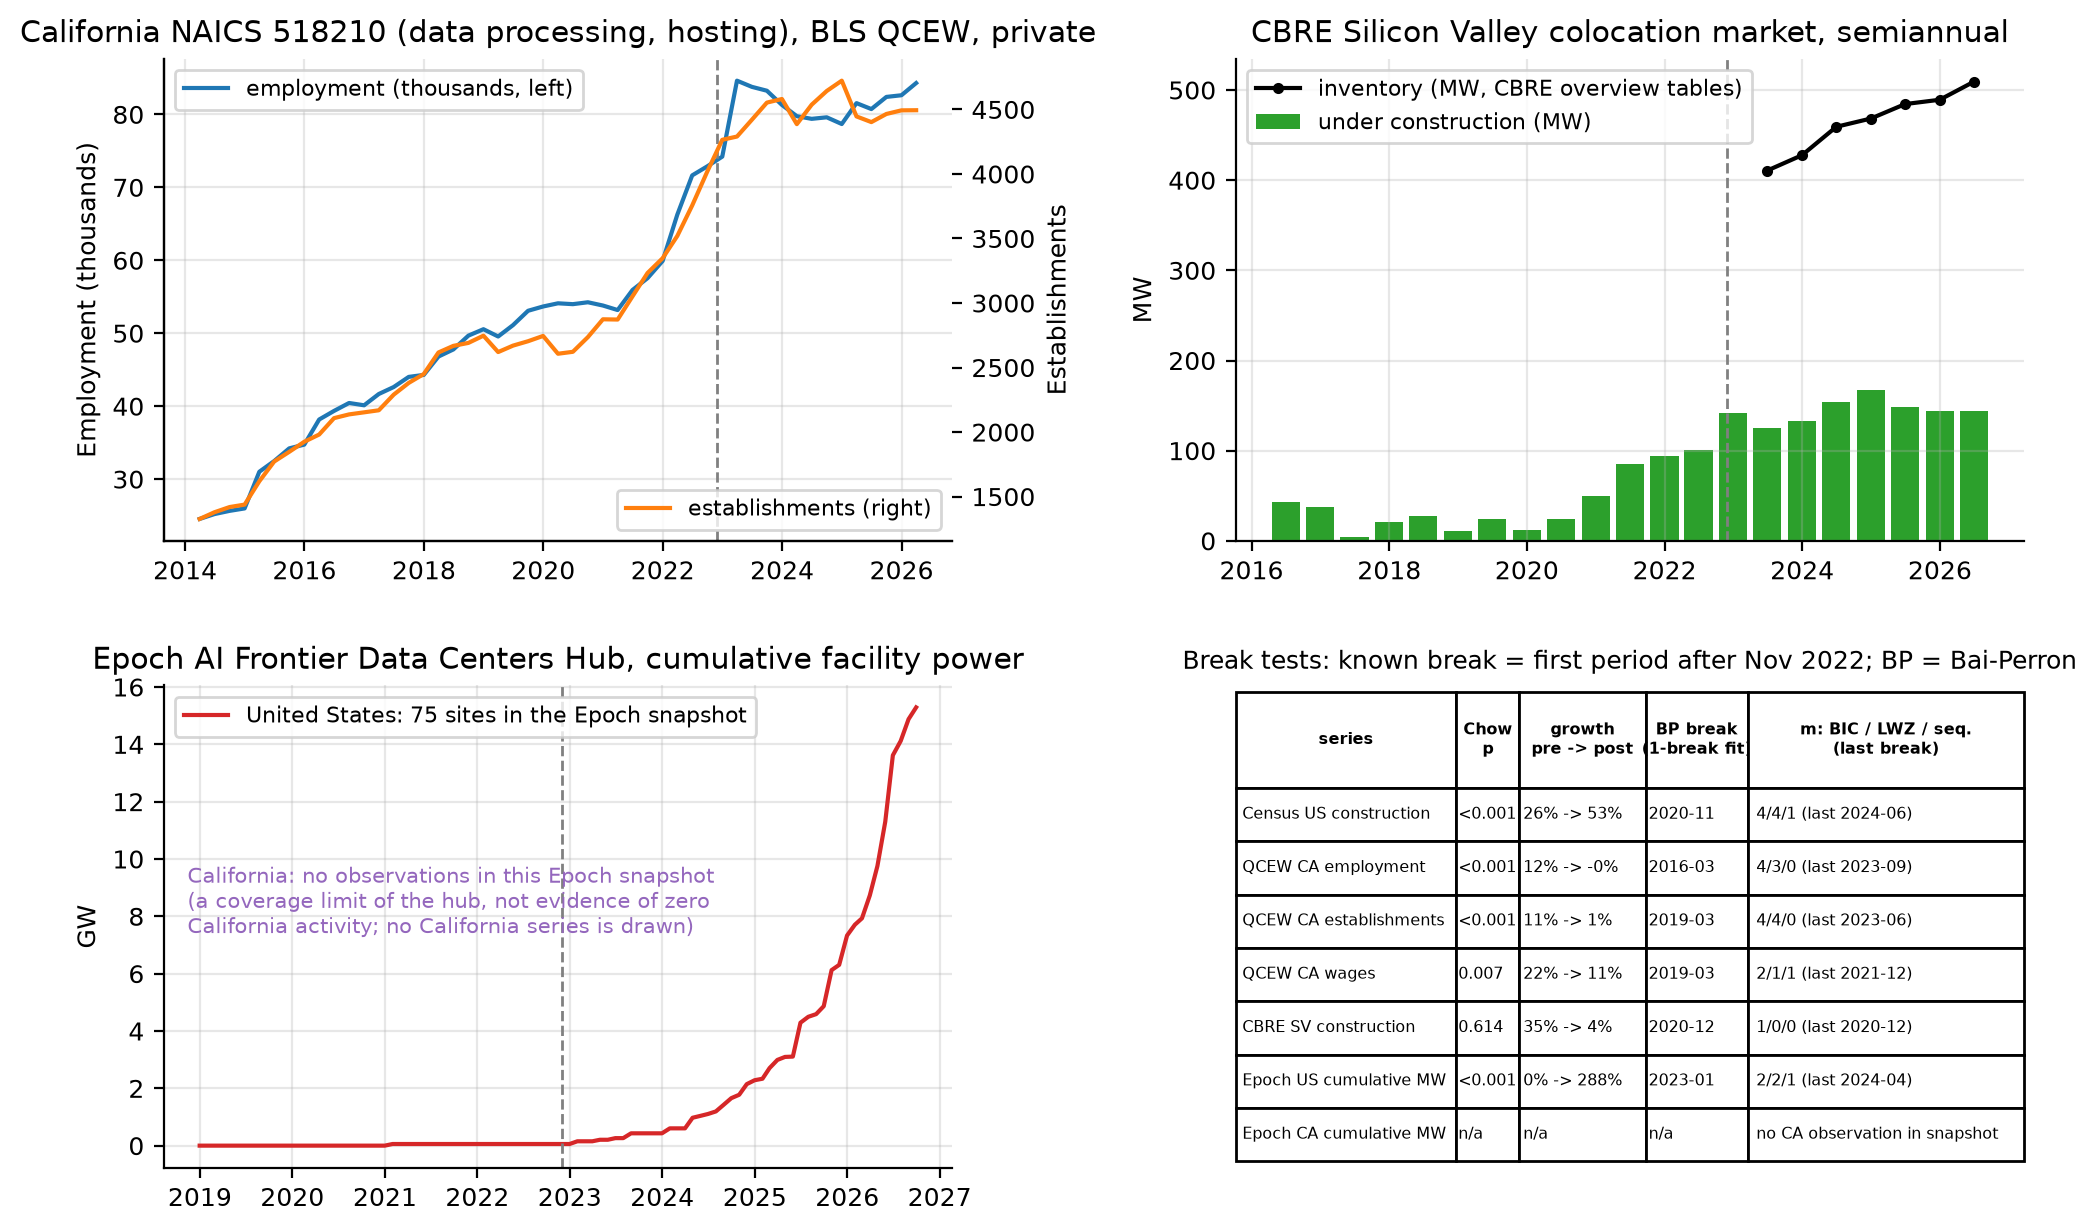

In [13]:
show("fig2_03_california_proxies")

In [14]:
q = table("ch2_qcew_518210_california"); q["fips"] = q.fips.astype(str).str.zfill(5)
st = q[q.fips=="06000"].set_index("period")[["qtrly_estabs","employment","total_qtrly_wages"]]
st.iloc[[0, 8, 16, 24, 31, 32, 36, 40, -1]]

,qtrly_estabs,employment,total_qtrly_wages
period,,,
2014-03-31,1327,24544.333333,756734886
2016-03-31,1981,38172.333333,1348909747
2018-03-31,2617,46807.000000,2710910258
2020-03-31,2607,54103.333333,2902913726
2021-12-31,3347,59904.000000,5119860578
2022-03-31,3520,66261.666667,4165162947
2023-03-31,4290,84623.000000,5170479387
2024-03-31,4386,79752.666667,5763605974
2026-03-31,4494,84295.333333,7191825181


In [15]:
cb = table("ch2_cbre_california"); cb[(cb.kind=="chapter_history")&(cb.metric=="under_construction_mw")][["period","value","edition"]].reset_index(drop=True).T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
period,H1 2016,H2 2016,H1 2017,H2 2017,H1 2018,H2 2018,H1 2019,H2 2019,H1 2020,H2 2020,H1 2021,H2 2021,H1 2022,H2 2022,H1 2023,H2 2023,H1 2024,H2 2024,H1 2025,H2 2025,H1 2026
value,43.5,37.5,4.5,21.0,28.0,11.0,24.0,12.0,24.6,50.1,85.3,94.6,100.6,141.6,125.0,133.0,154.2,167.8,148.8,144.0,144.0
edition,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H2 2025 chapter history,H1 2026 chapter history


**Reading.** The California proxies move the opposite way from the national construction series. QCEW employment in data processing and hosting grew 12 percent a year from 2014 through 2022 (25,000 to 74,000 jobs), then flattened (−0.3 percent a year after 2023 Q1, Chow F = 15, p < 0.001); establishments show the same pattern (11 percent to 0.5 percent). Data-located breaks in these quarterly series are diffuse: BIC places four breaks in each (the last in 2023 Q3 and 2023 Q2), the single-break bootstrap is significant for employment (p = 0.035) but not establishments (p = 0.285), and the sequential procedure keeps none. Silicon Valley's construction pipeline rose from about 44 MW in 2016 to 142 MW by late 2022 and has since sat between 125 and 168 MW with no break at 2023 (Chow p = 0.61; BIC one break at H2 2020, LWZ and sequential none), while the national frontier-site series went from nothing to 15 GW (a reconstruction from sampled sites). Epoch's snapshot has no California observation (coverage, not a count of zero). In short, the post-2022 boom shows up in California only as requests to connect, not as built or staffed capacity, which is consistent with the power constraints Silicon Valley Power and CBRE both describe.

## 4. Every vintage of the CEC energization tiers

Vintages found in the record: December 2024 (PG&E and SCE agreements plus applications, from the 2024 IEPR Update comparison), summer 2025 (seven utilities; PG&E and SCE split into agreements plus applications versus inquiries from the published deck's page 7, the other five as totals), December 2025 (seven utilities by tier, methodology memo Table 1 and the Assembly slide), the August 2026 workshop (restates December 2025), SCE's two public project databases (August 2025 and January 2026, the only vintages with cancellations), and PG&E's own pipeline by PG&E stage from its Q2 2026 earnings table (March and June 2026, reproduced in TN 272065). The workshop copy of the preliminary deck (TN 267165) labelled SCE's summer-2025 agreements plus applications as 2,492 MW and SVP's total as 1,382 MW; the published deck corrects these to 143 and 1,375 MW and the corrected values are used. VEA's 2,600 MW (summer 2025 and December 2025) are located in Nevada per the memo footnote and are separated from the California-only totals (19,156 and 20,677 MW); SCE's canceled requests are shown separately from its active pipeline. The June 2026 known-load charts in the 2026 IEPR workshop are images without numbers; the monthly snapshot watches docket 26-IEPR-03 for the next vintage.

In [16]:
tv = table("ch2_tier_vintages"); tv.pivot_table(index=["vintage","label"], columns="tier", values="mw", aggfunc="sum").fillna(0).round(0)

tier                                           Active application  Agreements + applications (no inquiries)  All tiers  Canceled  Inquiry  PG&E: application + preliminary engineering  \
vintage label                                                                                                                                                                            
2024-12 Dec 2024 (2024 IEPR Update)                           0.0                                    6771.0        0.0       0.0      0.0                                          0.0   
2025-08 SCE database Aug 29 2025                            216.0                                       0.0        0.0     709.0   5934.0                                          0.0   
        Summer 2025 (2025 IEPR preliminary)                   0.0                                   10223.0     4260.0       0.0   7273.0                                          0.0   
2025-12 Dec 2025 (2025 IEPR final)                         9587.0                                       0.0        0.0       0.0   8605.0                                          0.0   
2026-01 SCE database Jan 29 2026                           3313.0                                       0.0        0.0    3137.0   1772.0                                          0.0   
2026-03 PG&E earnings pipeline Mar 2026                       0.0                                       0.0        0.0       0.0      0.0                                       1700.0   
2026-06 PG&E earnings pipeline Jun 2026                       0.0                                       0.0        0.0       0.0      0.0                                       8200.0   
2026-08 Aug 2026 workshop (restates Dec 2025)                 0.0                                       0.0        0.0       0.0      0.0                                          0.0   

tier                                           PG&E: construction  PG&E: final engineering (WPA signed)  PG&E: interconnection construction agreement  Signed agreement  Total restated  
vintage label                                                                                                                                                                            
2024-12 Dec 2024 (2024 IEPR Update)                           0.0                                   0.0                                           0.0               0.0             0.0  
2025-08 SCE database Aug 29 2025                              0.0                                   0.0                                           0.0              51.0             0.0  
        Summer 2025 (2025 IEPR preliminary)                   0.0                                   0.0                                           0.0               0.0             0.0  
2025-12 Dec 2025 (2025 IEPR final)                            0.0                                   0.0                                           0.0            5086.0             0.0  
2026-01 SCE database Jan 29 2026                              0.0                                   0.0                                           0.0              76.0             0.0  
2026-03 PG&E earnings pipeline Mar 2026                     140.0                                3110.0                                         140.0               0.0             0.0  
2026-06 PG&E earnings pipeline Jun 2026                     140.0                                3880.0                                         490.0               0.0             0.0  
2026-08 Aug 2026 workshop (restates Dec 2025)                 0.0                                   0.0                                           0.0               0.0         23278.0

In [17]:
tv[tv.note.astype(str).str.len() > 0][["vintage","label","utility","tier","mw","note"]]

,vintage,label,utility,tier,mw,note
0,2024-12,Dec 2024 (2024 IEPR Update),PG&E,Agreements + applications (no inquiries),5808.000000,NaN
1,2024-12,Dec 2024 (2024 IEPR Update),SCE,Agreements + applications (no inquiries),963.000000,NaN
2,2025-08,Summer 2025 (2025 IEPR preliminary),PG&E,Agreements + applications (no inquiries),10080.000000,NaN
3,2025-08,Summer 2025 (2025 IEPR preliminary),PG&E,Inquiry,1588.000000,residual: utility total minus agreements + applications
4,2025-08,Summer 2025 (2025 IEPR preliminary),SVP,All tiers,1375.000000,"workshop copy TN267165 p.7 labelled SVP as 1,382 MW; published deck says 1,3..."
5,2025-08,Summer 2025 (2025 IEPR preliminary),Palo Alto,All tiers,85.000000,NaN
6,2025-08,Summer 2025 (2025 IEPR preliminary),SCE,Agreements + applications (no inquiries),143.000000,"workshop copy TN267165 p.8 labelled SCE 2025 as 2,492 MW; published deck say..."
7,2025-08,Summer 2025 (2025 IEPR preliminary),SCE,Inquiry,5685.000000,residual: utility total minus agreements + applications
8,2025-08,Summer 2025 (2025 IEPR preliminary),SDG&E,All tiers,100.000000,NaN
9,2025-08,Summer 2025 (2025 IEPR preliminary),Burbank,All tiers,100.000000,NaN


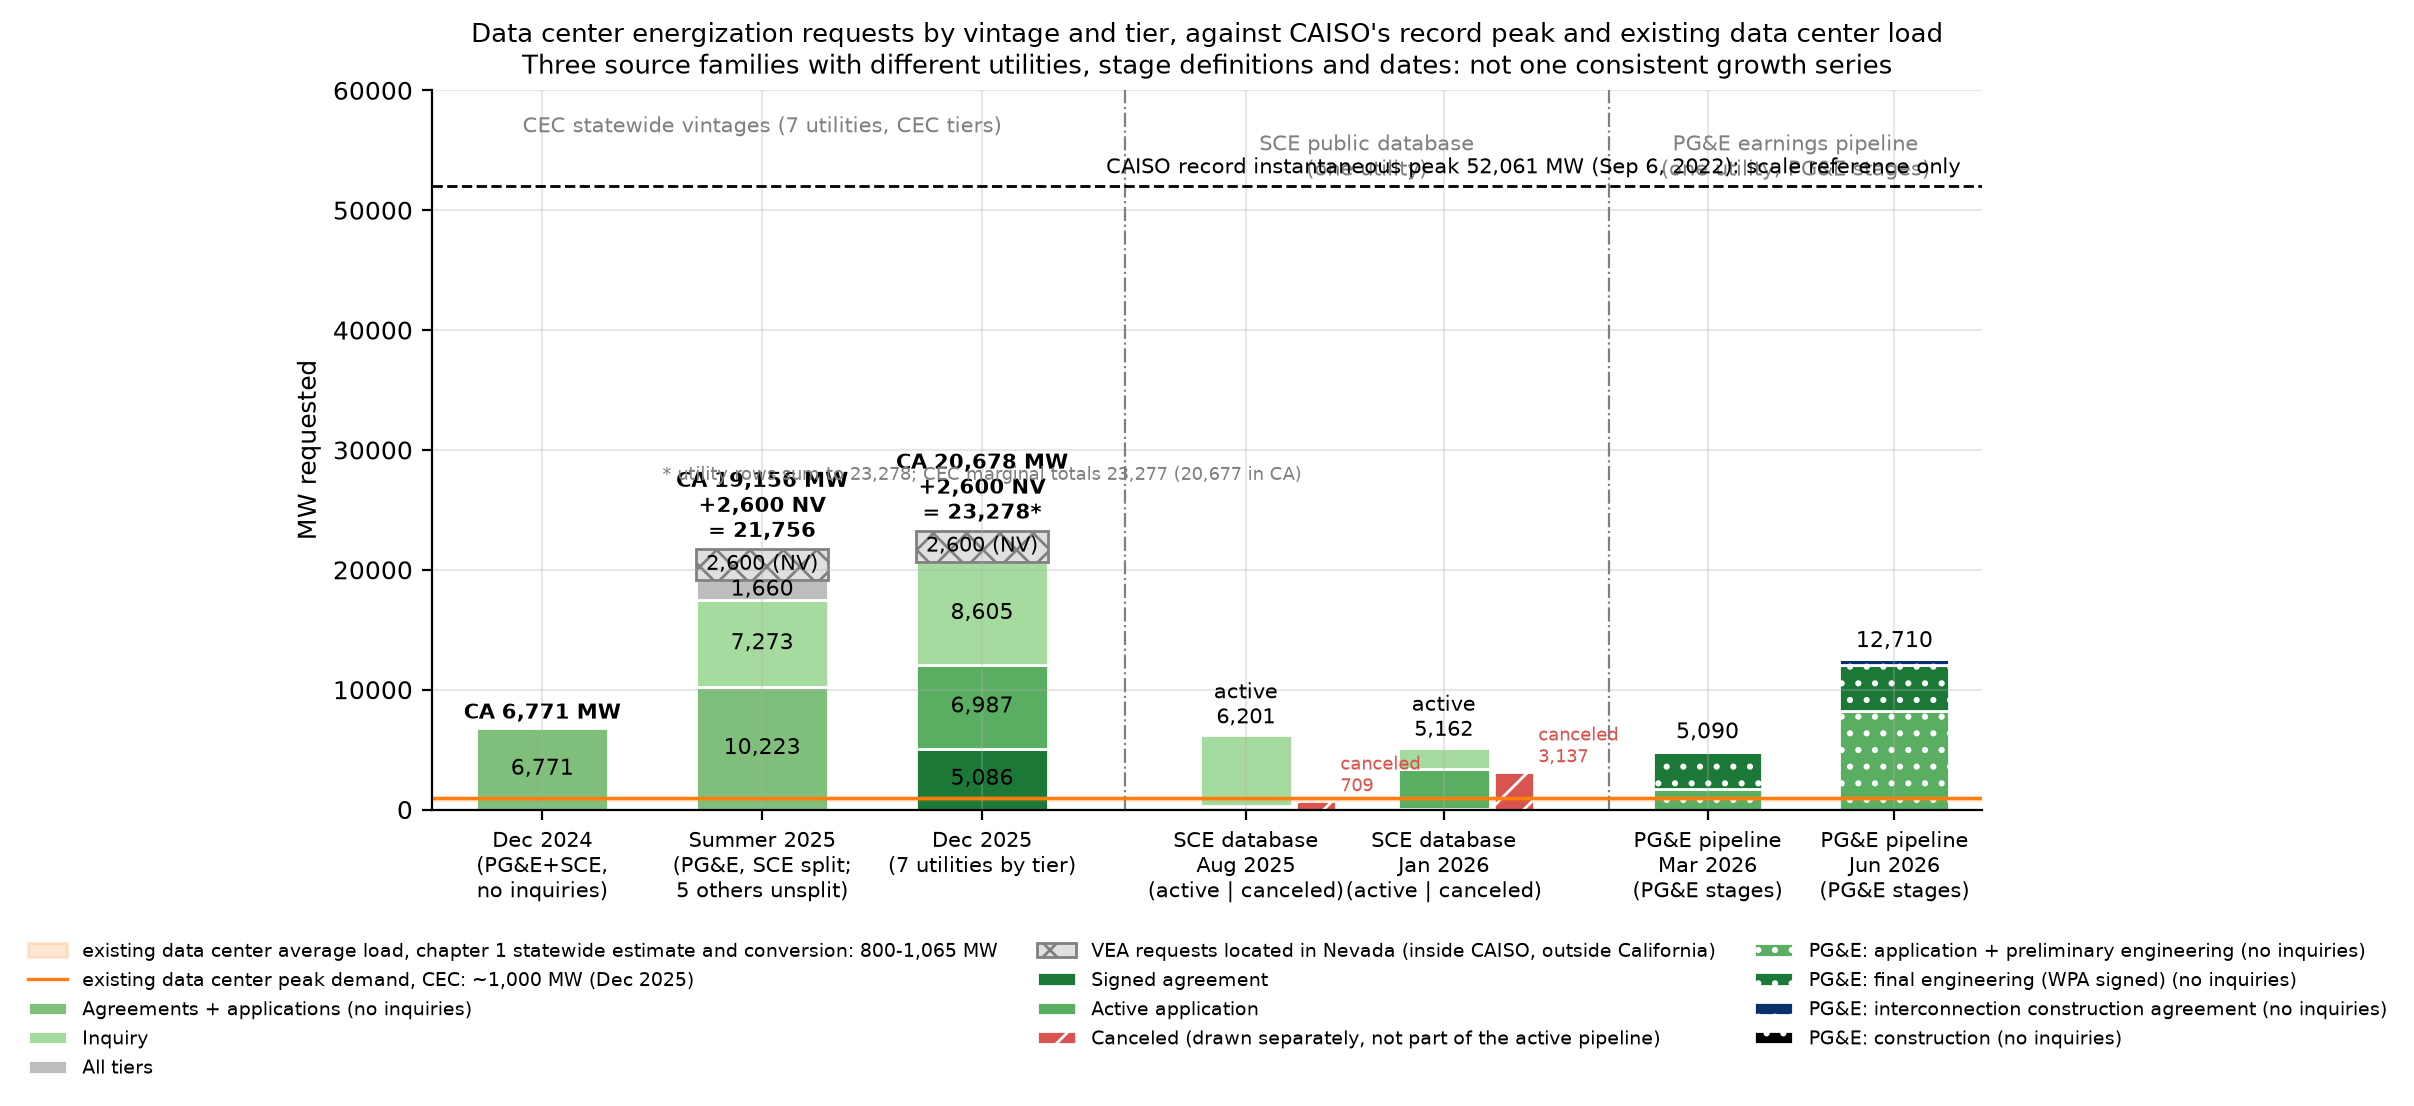

In [18]:
show("fig2_04_tier_vintages")

In [19]:
table("ch2_cec_forecast_reference_points")

,vintage,scenario,year,mw,note,source
0,2024-12,2024 IEPR Update mid (Dec),2024,987,existing + forecast total data center peak demand,cec_dc_forecast_2024iepr p.9
1,2024-12,2024 IEPR Update mid (Dec),2025,1190,NaN,cec_dc_forecast_2024iepr p.9
2,2024-12,2024 IEPR Update mid (Dec),2030,3294,NaN,cec_dc_forecast_2024iepr p.9
3,2024-12,2024 IEPR Update mid (Dec),2040,4507,NaN,cec_dc_forecast_2024iepr p.9
4,2025-12,2025 IEPR Planning (mid),2025,413,"incremental beyond ~1,000 MW existing",cec_dc_methodology_memo_2026 Fig. 4
5,2025-12,2025 IEPR Planning (mid),2040,4855,incremental,cec_dc_methodology_memo_2026 Fig. 4
6,2025-12,2025 IEPR Local Reliability (high),2025,684,incremental,cec_dc_methodology_memo_2026 Fig. 5
7,2025-12,2025 IEPR Local Reliability (high),2040,7381,incremental,cec_dc_methodology_memo_2026 Fig. 5
8,2025-12,Existing data center peak demand,2025,1000,as of December 2025,cec_dc_methodology_memo_2026 p.2


**Reading.** Requests grew from 6,771 MW (December 2024, two utilities, no inquiries) to 21,756 MW (summer 2025; PG&E 10,080 MW in agreements plus applications and 1,588 MW in inquiries, SCE 143 and 5,685 MW) and 23,277 MW (December 2025): 5,086 MW signed, 9,587 MW in application, 8,604 MW in inquiry. Of these, VEA's 2,600 MW of applications are in Nevada, so the California-only totals are 19,156 MW (summer 2025) and 20,677 MW (December 2025). The three source families (CEC vintages, SCE database, PG&E pipeline) differ in utilities, stages and dates and are not one growth series. PG&E's own pipeline (PG&E stages, no inquiries) then went from 5,090 MW in March 2026 to 12,710 MW in June 2026 after the 2026 cluster study, with 3,880 MW at signed work performance agreement, 490 MW at interconnection construction agreement and 140 MW in construction; Cal Advocates notes PG&E had filed only about 650 MW of such agreements with the CPUC. The sum is 45 percent of CAISO's record peak of 52,061 MW and 23 times the roughly 1,000 MW of existing data center peak demand the CEC reports, or 10 to 29 times the chapter 1 range of existing average load. SCE's public database shows what happens inside a vintage: between August 2025 and January 2026 its inquiries fell from 5,934 MW to 1,772 MW as 3,100 MW moved into applications, and canceled requests rose from 709 MW to 3,137 MW, and the active total fell from 6,201 to 5,162 MW, so the growth in SCE's records is cancellations: 38 percent of everything SCE had ever logged was canceled within five months.

## 5. RQ1: the pipeline by stage against the grid, existing load and the adopted forecast

In [20]:
rq = table("ch2_rq1_table"); rq.round(1)

,stage,mw,share_of_caiso_record_peak_pct,share_of_caiso_2025_peak_pct,multiple_of_existing_dc_peak_1000MW,multiple_of_existing_dc_avg_load_range,share_of_IEPR_planning_managed_net_peak_growth_2025_2030_pct,share_of_IEPR_planning_baseline_consumption_peak_growth_2025_2030_pct,expected_demand_at_67pct_utilization_mw,expected_demand_share_of_managed_net_peak_growth_pct,energy_equivalent_GWh_at_67pct_util_and_0p88_lf,energy_share_of_IEPR_statewide_energy_growth_2025_2030_pct
0,Signed agreements,5086.0,9.8,11.6,5.1,4.8-6.4,126.5,89.6,3407.6,84.8,26268.7,75.1
1,"Active applications, California",6987.0,13.4,15.9,7.0,6.6-8.7,173.8,123.1,4681.3,116.5,36087.1,103.2
2,Inquiries,8604.0,16.5,19.6,8.6,8.1-10.8,214.1,151.5,5764.7,143.4,44438.8,127.1
3,"Total, three tiers, California only",20677.0,39.7,47.1,20.7,19.4-25.8,514.5,364.2,13853.6,344.7,106794.6,305.4
4,Memo: VEA applications located in Nevada,2600.0,5.0,5.9,2.6,2.4-3.2,64.7,45.8,1742.0,43.3,13428.7,38.4
5,Memo: CEC statewide total including VEA,23277.0,44.7,53.1,23.3,21.9-29.1,579.2,410.0,15595.6,388.0,120223.3,343.8


In [21]:
den = json.loads((PROCESSED / "ch2_rq1_denominators.json").read_text()); {k: round(v, 1) for k, v in den.items()}

{'caiso_record_peak_mw': 52061.0,
 'caiso_record_hourly_eia930_mw': 51104.0,
 'caiso_2025_peak_mw': 43860.0,
 'existing_dc_peak_mw_cec': 1000.0,
 'existing_dc_avg_load_mw_low': 800.0,
 'existing_dc_avg_load_mw_high': 1065.1,
 'iepr_planning_caiso_managed_net_peak_2025_mw': 46479.0,
 'iepr_planning_caiso_managed_net_peak_2030_mw': 50498.0,
 'iepr_planning_caiso_baseline_consumption_peak_2025_mw': 50502.0,
 'iepr_planning_caiso_baseline_consumption_peak_2030_mw': 56180.0,
 'iepr_planning_data_center_at_caiso_peak_2025_mw': 96.0,
 'iepr_planning_data_center_at_caiso_peak_2030_mw': 1743.0,
 'iepr_planning_statewide_energy_growth_2025_2030_GWh': 34971.0,
 'iepr_planning_statewide_data_center_deliveries_2030_GWh': 12078.1,
 'iepr_planning_statewide_data_center_deliveries_2025_GWh': 729.1,
 'iepr_planning_statewide_energy_2025_GWh': 263195.7,
 'iepr_planning_statewide_energy_2030_GWh': 298166.7,
 'total_tiers_mw': 20677.0,
 'total_tiers_mw_california': 20677.0,
 'vea_nevada_applications_mw': 

In [22]:
table("ch2_ced2025_planning_totals")[["metric","scope","y2025","y2030","y2040"]].round(0)

,metric,scope,y2025,y2030,y2040
0,energy_to_serve_load,Statewide total,263196.0,298167.0,399850.0
1,net_peak_1in2,Statewide coincident,57560.0,62832.0,75452.0
2,net_peak_1in2,Statewide noncoincident,60343.0,65522.0,78208.0
3,deliveries_total,Statewide total,242843.0,273316.0,364460.0
4,deliveries_total,Statewide excl. pumping,234598.0,265071.0,356215.0
5,data_center_deliveries,Statewide total (sum of planning-area totals),729.0,12078.0,32630.0
6,data_center_deliveries,PG&E Total,660.0,10940.0,27023.0
7,data_center_deliveries,SCE Total,69.0,1138.0,5607.0
8,data_center_deliveries,SDG&E Total,0.0,0.0,0.0
9,data_center_deliveries,NCNC Total,0.0,0.0,0.0


**Answer to RQ1.** By stage, the planned data center capacity located in California is 5,086 MW signed, 6,987 MW in application and 8,604 MW in inquiry, 20,677 MW in total (December 2025; the CEC's reported 23,277 MW includes 2,600 MW of VEA applications in Nevada). That total is 40 percent of CAISO's record instantaneous peak (a scale comparison, not a coincident ratio) and 47 percent of the 2025 peak; 21 times the state's existing data center peak demand and 19-26 times the existing average load implied by the chapter 1 statewide estimate and conversion; and 5.1 times the growth in CAISO's managed net peak that the adopted 2025 IEPR planning forecast projects between 2025 and 2030 (4,019 MW). Even at the CEC's 67 percent utilization the pipeline is 3.4 times that growth, and its energy equivalent (about 107 TWh a year) is 3.1 times the statewide energy growth the forecast expects over the same period. Requests are not simultaneous demand and signed agreements are not operating capacity. The CEC's own forecast already embeds part of this: its data center component at the CAISO peak rises from 96 MW in 2025 to 1,743 MW in 2030 in the planning scenario (4,377 MW in the local-reliability scenario), and its data-center-only deliveries reach 12.1 TWh in 2030, about a third of projected statewide energy growth. The gap between requests and forecast is the object of the rest of the study.